## What is The Most Optimal Skill to Learn for Data Scientists

### Import Libraries and Data

In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# Loading Data
df = pd.read_csv(r'C:\Users\baw61\Downloads\job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Clean Data

In [2]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_US_exploded = df_DS_US.explode('job_skills')
df_DS_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
45,NaN,sql
45,NaN,python
45,NaN,tableau
46,NaN,sql
46,NaN,python


### Calculate Percent of Job Postings that Have Skills

In [3]:
df_DS_skills = (
    df_DS_US_exploded
    .groupby('job_skills')
    .agg(
        skill_count=('job_skills', 'size'),
        median_salary=('salary_year_avg', 'median')
    )

    .sort_values(by='skill_count', ascending=False)
)

DS_job_count = len(df_DS_US)
df_DS_skills['skill_percent'] = df_DS_skills['skill_count'] / DS_job_count * 100

skill_percent = 10

df_DS_skills_high_demand = df_DS_skills[df_DS_skills['skill_percent'] > skill_percent]
df_DS_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
python,92859,137500.0,65.142268
sql,65460,137500.0,45.921374
r,52208,135000.0,36.624856
tableau,27651,125000.0,19.397677
sas,27618,120631.0,19.374526
aws,24120,142500.0,16.920616
spark,19829,150000.0,13.910402
tensorflow,16879,150000.0,11.840924
azure,16683,135000.0,11.703426


### Coloring by Technology

In [4]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['dax',
  'qlik',
  'esquisse',
  'sas',
  'ssis',
  'ms access',
  'splunk',
  'sharepoint',
  'powerpoint',
  'nuix',
  'powerbi',
  'datarobot',
  'ssrs',
  'looker',
  'sap',
  'sheets',
  'spss',
  'outlook',
  'spreadsheet',
  'tableau',
  'power bi',
  'cognos',
  'visio',
  'alteryx',
  'excel',
  'microstrategy',
  'word'],
 'async': ['workfront',
  'workzone',
  'confluence',
  'jira',
  'clickup',
  'notion',
  'monday.com',
  'swit',
  'wrike',
  'airtable',
  'microsoft lists',
  'planner',
  'dingtalk',
  'trello',
  'smartsheet',
  'wimi',
  'asana'],
 'cloud': ['aurora',
  'redshift',
  'azure',
  'vmware',
  'bigquery',
  'oracle',
  'openstack',
  'aws',
  'watson',
  'databricks',
  'heroku',
  'firebase',
  'ibm cloud',
  'snowflake',
  'gcp',
  'colocation',
  'ovh',
  'linode',
  'digitalocean'],
 'programming': ['solidity',
  'lua',
  'sass',
  'html',
  'dart',
  'crystal',
  'c++',
  'sas',
  'assembly',
  'shell',
  'css',
  'lisp',
  'delphi

### Join DataFrames

In [5]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')
df_plot = df_DS_skills_high_demand.merge(df_technology, left_on='job_skills',right_on='skills')

### Plotting Findings on Scatterplot

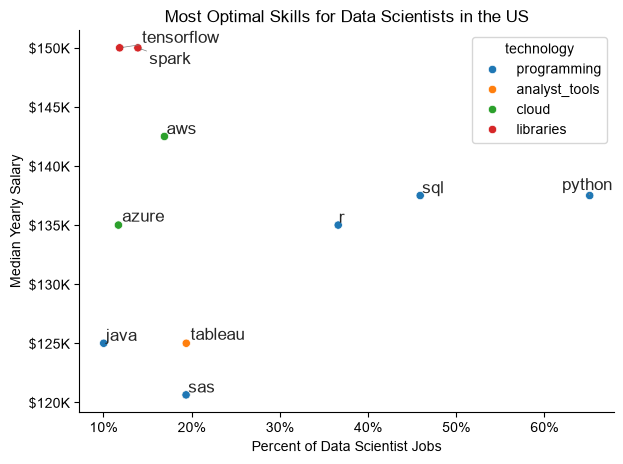

In [6]:
from adjustText import adjust_text

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)


sns.despine()
sns.set_theme(style='ticks')
texts = []
for i, txt in enumerate(df_DS_skills_high_demand.index):
    texts.append(plt.text(df_DS_skills_high_demand['skill_percent'].iloc[i], df_DS_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

from matplotlib.ticker import PercentFormatter 
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())

plt.xlabel('Percent of Data Scientist Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Scientists in the US')


plt.tight_layout()
plt.show()